<a href="https://colab.research.google.com/github/abhinavmishragsv-analytics/DL-Lab/blob/second-lab/ArtificialBrainSurgery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

                    ARTIFICIAL BRAIN SURGERY

EPOCH 9/10
---------------------------------------------------------------------------
Training Loss     : 0.036484
Training Accuracy : 98.9833%
Test Accuracy     : 97.7600%

NETWORK ARCHITECTURE
-------------------------------------------------------
Input Layer       : 784 neurons
Hidden Layer      : 128 neurons — ReLU
Output Layer      : 10 neurons — Softmax

W1 : 784 × 128 = 100352 weights
W2 : 128 × 10  = 1280 weights
Total Weights    : 101632

CURRENT STIMULUS
-------------------------------------------------------
True Digit       : 7
Prediction       : 7
Confidence       : 99.8798%


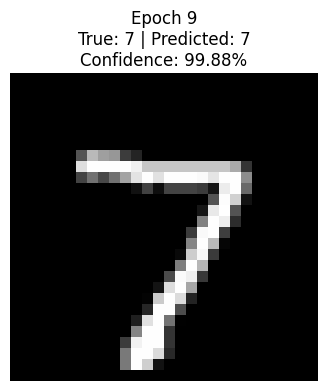


                         WEIGHT VITALS

W1 — INPUT → HIDDEN
-------------------------------------------------------
Minimum   : -0.777542
Maximum   :  0.491441
Mean      : -0.001818
Std Dev   :  0.101105
L2 Norm   :  32.033703

W2 — HIDDEN → OUTPUT
-------------------------------------------------------
Minimum   : -1.092119
Maximum   :  0.725788
Mean      : -0.034821
Std Dev   :  0.272744
L2 Norm   :  9.837176

                    EXTREME WEIGHT LOCATIONS

W1 Minimum : -0.777542
W1 Min Position : (np.int64(513), np.int64(19))

W1 Maximum : 0.491441
W1 Max Position : (np.int64(748), np.int64(114))

W2 Minimum : -1.092119
W2 Min Position : (np.int64(106), np.int64(4))

W2 Maximum : 0.725788
W2 Max Position : (np.int64(37), np.int64(7))

                         GRADIENT VITALS
W1 Average Gradient L2 Norm : 0.218666
W2 Average Gradient L2 Norm : 0.187662

HIDDEN LAYER HEALTH
-------------------------------------------------------
Dead ReLU Neurons : 0/128

EXTREME WEIGHT BANDS
---------

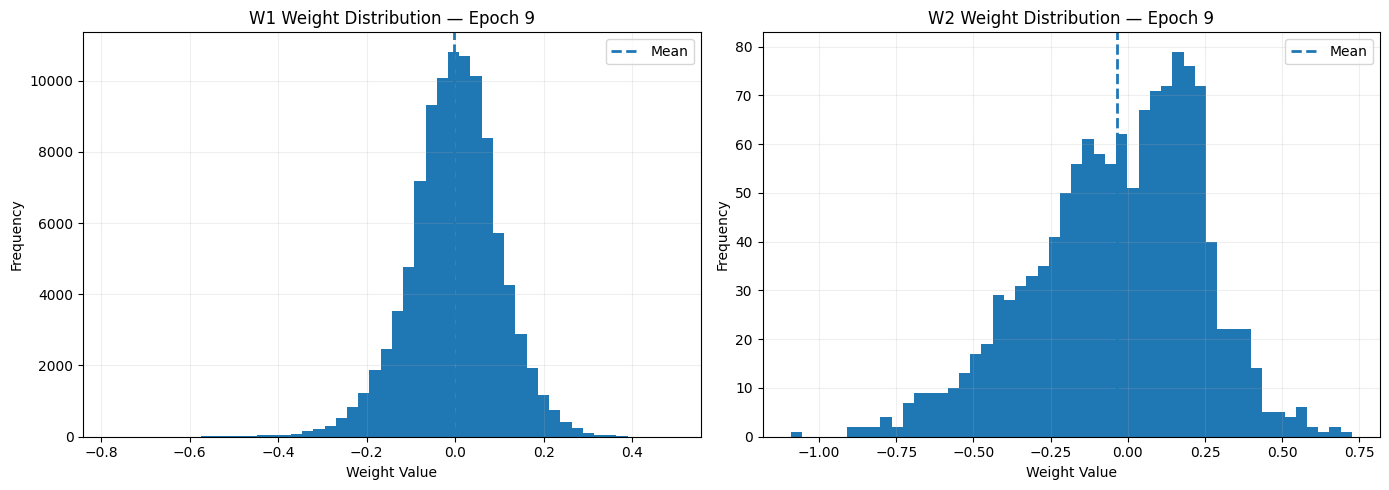


                W1 SPATIAL WEIGHT PATTERNS


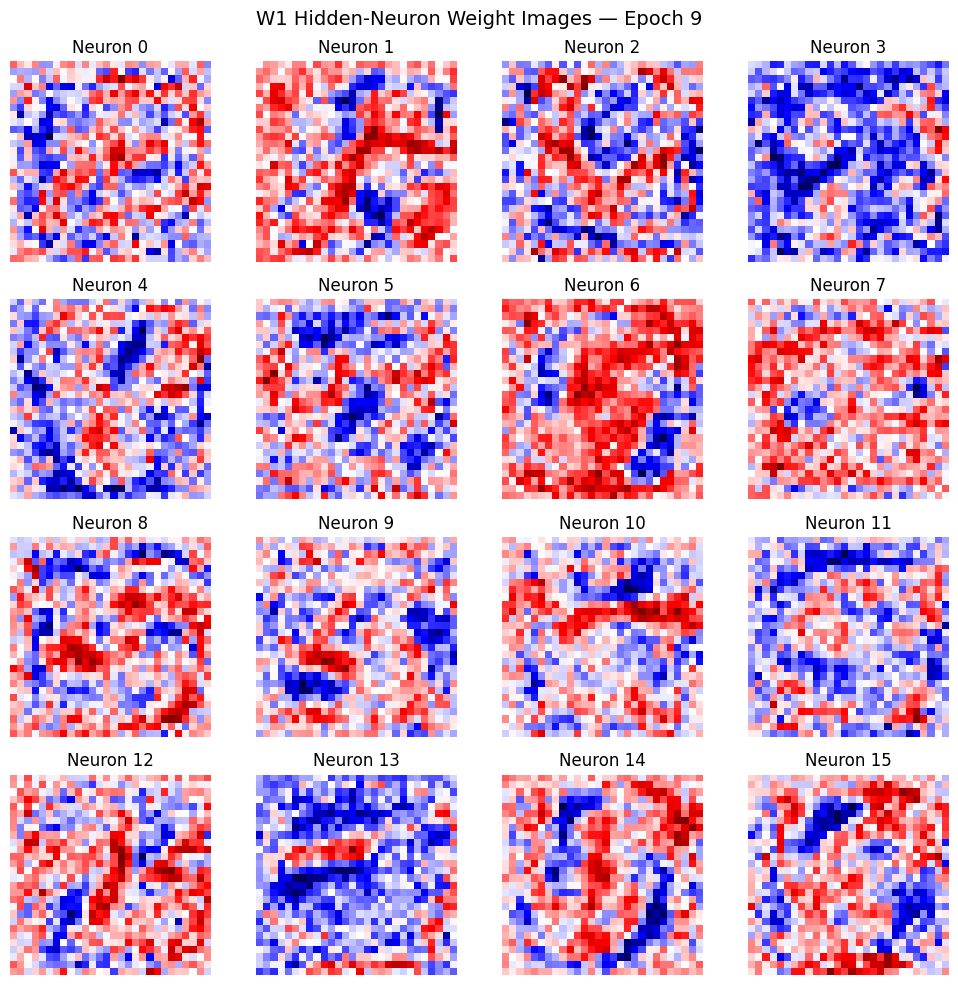


                    LEARNING EVOLUTION


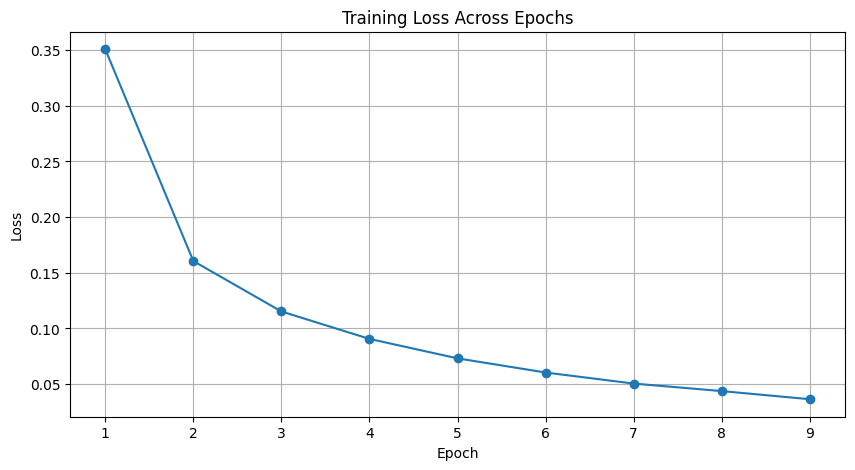

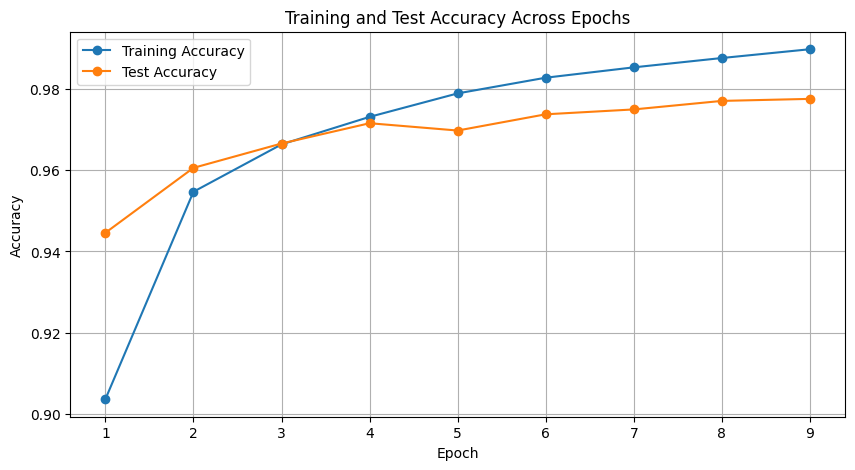

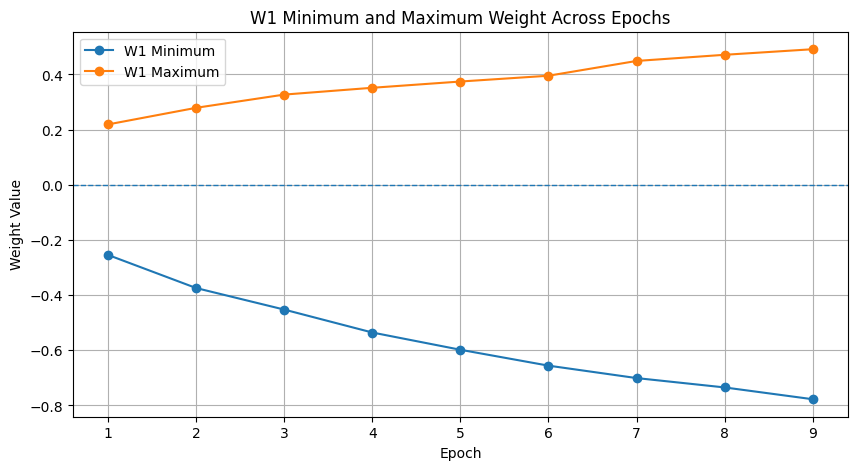

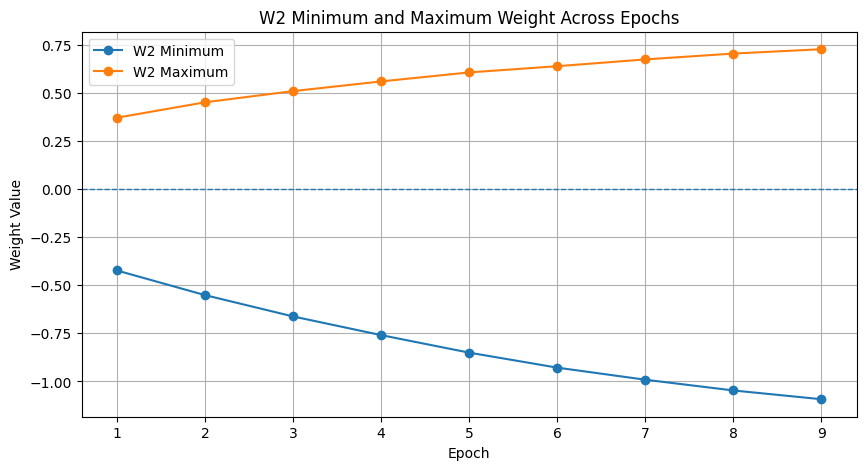

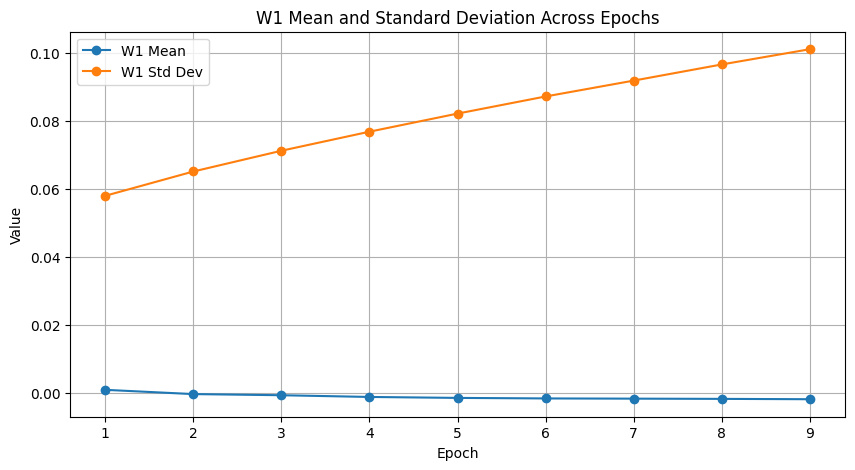

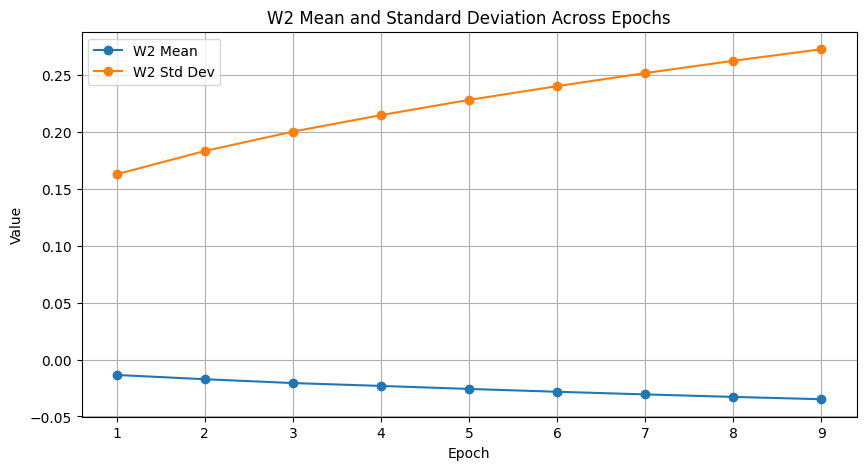

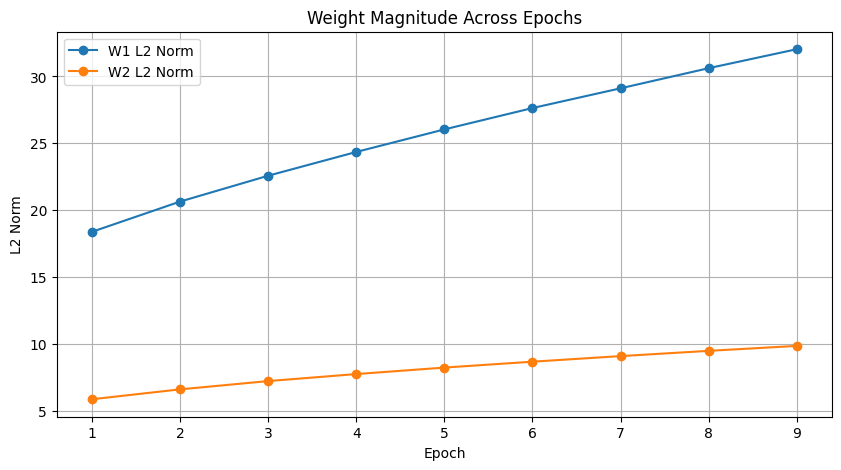

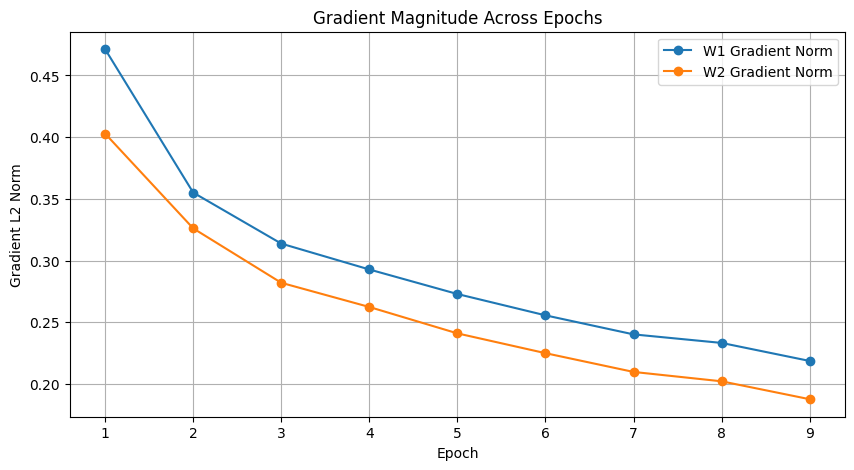

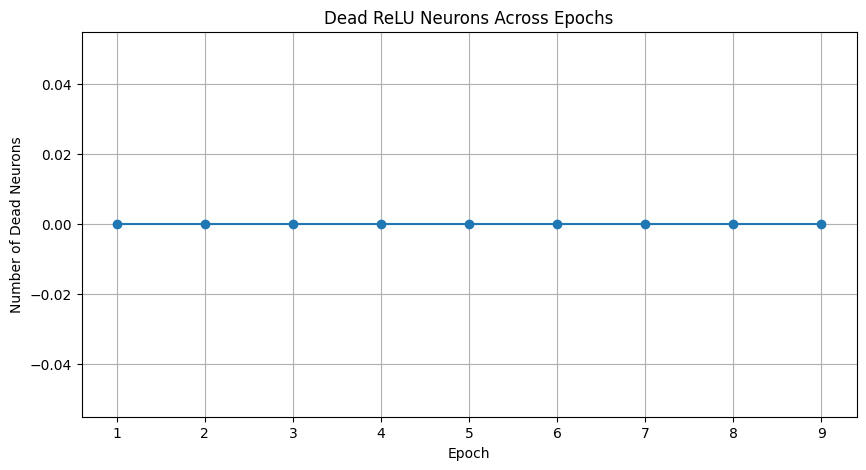

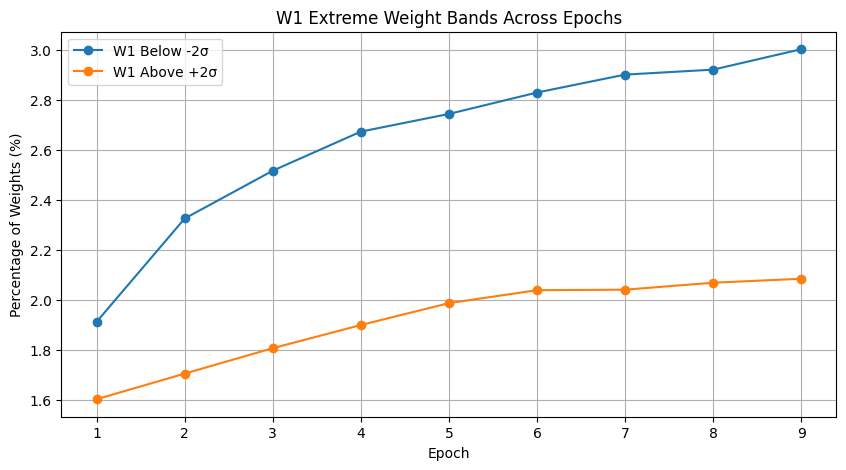

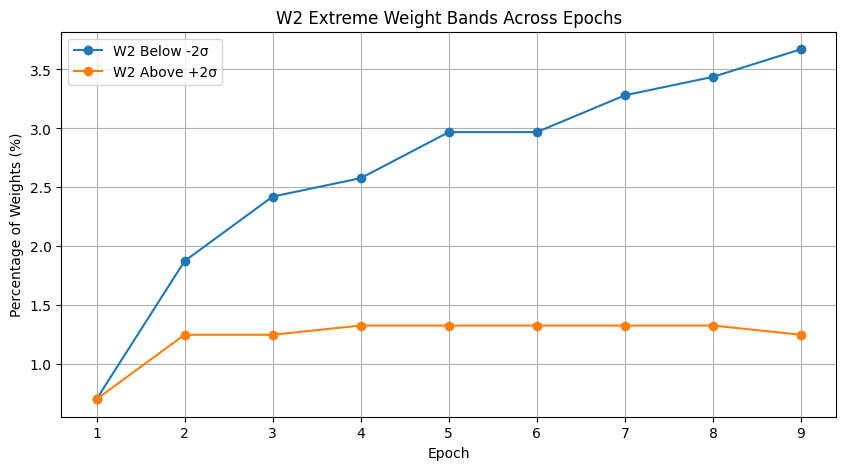

In [ ]:
# ============================================================
#                 ARTIFICIAL BRAIN SURGERY
#              MNIST MLP WITH WEIGHT DIAGNOSTICS
#
# Architecture:
#               784 → 128 → 10
#
# Framework:
#               TensorFlow
#
# Diagnostics after EVERY epoch:
#   1. W1/W2 min, max, mean, std, L2 norm
#   2. W1/W2 histograms
#   3. W1 minimum/maximum evolution
#   4. W2 minimum/maximum evolution
#   5. W1 weight-image patterns
#   6. Fixed MNIST stimulus
#   7. Training/Test accuracy
#   8. Training loss
#   9. Gradient norms
#  10. Dead ReLU neurons
#  11. Extreme weight bands
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import clear_output

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)


# ============================================================
# 2. LOAD MNIST DATASET
# ============================================================

(X_train, y_train), (X_test, y_test) = (
    tf.keras.datasets.mnist.load_data()
)

# Normalize pixel values from [0, 255] → [0, 1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Convert labels to int64
# This prevents dtype mismatch during comparisons
y_train = y_train.astype("int64")
y_test = y_test.astype("int64")

print("\nDATASET INFORMATION")
print("-" * 55)

print("Training data :", X_train.shape)
print("Training labels:", y_train.shape)

print("Testing data  :", X_test.shape)
print("Testing labels:", y_test.shape)

print("Label datatype:", y_train.dtype)


# ============================================================
# 3. CREATE THE MLP
# ============================================================

model = tf.keras.Sequential([

    # Input
    tf.keras.Input(shape=(28, 28)),

    # 28 × 28 = 784
    tf.keras.layers.Flatten(),

    # Hidden layer
    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    # Output layer
    tf.keras.layers.Dense(
        10,
        activation="softmax"
    )
])


# ============================================================
# 4. DISPLAY MODEL ARCHITECTURE
# ============================================================

print("\nNETWORK ARCHITECTURE")
print("-" * 55)

model.summary()


# ============================================================
# 5. EXTRACT INITIAL WEIGHTS
# ============================================================

W1, b1 = model.layers[1].get_weights()
W2, b2 = model.layers[2].get_weights()

print("\nINITIAL CONNECTION INFORMATION")
print("-" * 55)

print("W1 Shape:", W1.shape)
print("W2 Shape:", W2.shape)

print("\nW1 Parameters:", W1.size)
print("W2 Parameters:", W2.size)

print("Total Weights:", W1.size + W2.size)

print("Total Biases :", b1.size + b2.size)

print(
    "Total Trainable Parameters:",
    W1.size + W2.size + b1.size + b2.size
)


# ============================================================
# 6. DISPLAY INITIAL WEIGHTS
# ============================================================

print("\nINITIAL W1 CONNECTION MATRIX")
print("-" * 55)

print(W1)

print("\nINITIAL W2 CONNECTION MATRIX")
print("-" * 55)

print(W2)


# ============================================================
# 7. WEIGHT VITALS
# ============================================================

def weight_vitals(W, name):

    print(f"\n{name}")
    print("-" * 55)

    print(
        f"Minimum   : {np.min(W): .6f}"
    )

    print(
        f"Maximum   : {np.max(W): .6f}"
    )

    print(
        f"Mean      : {np.mean(W): .6f}"
    )

    print(
        f"Std Dev   : {np.std(W): .6f}"
    )

    print(
        f"L2 Norm   : {np.linalg.norm(W): .6f}"
    )


# Initial vitals

weight_vitals(
    W1,
    "W1 — INPUT → HIDDEN"
)

weight_vitals(
    W2,
    "W2 — HIDDEN → OUTPUT"
)


# ============================================================
# 8. FIND MINIMUM AND MAXIMUM LOCATIONS
# ============================================================

def weight_extreme_locations(W, name):

    min_index = np.unravel_index(
        np.argmin(W),
        W.shape
    )

    max_index = np.unravel_index(
        np.argmax(W),
        W.shape
    )

    print(f"\n{name} EXTREME VALUES")
    print("-" * 55)

    print(
        f"Minimum value : {W[min_index]:.6f}"
    )

    print(
        f"Minimum index : {min_index}"
    )

    print(
        f"Maximum value : {W[max_index]:.6f}"
    )

    print(
        f"Maximum index : {max_index}"
    )


weight_extreme_locations(
    W1,
    "W1"
)

weight_extreme_locations(
    W2,
    "W2"
)


# ============================================================
# 9. LOSS FUNCTION
# ============================================================

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()


# ============================================================
# 10. OPTIMIZER
# ============================================================

optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)


# ============================================================
# 11. TRAINING CONFIGURATION
# ============================================================

epochs = 10

batch_size = 128

# Full W1/W2 matrices are extremely large.
# They will be printed at:
#   - Epoch 1
#   - Every 5th epoch

matrix_print_frequency = 5


# ============================================================
# 12. CREATE TRAINING DATASET
# ============================================================

train_dataset = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train)
)

train_dataset = (
    train_dataset
    .shuffle(
        buffer_size=10000,
        seed=42,
        reshuffle_each_iteration=True
    )
    .batch(batch_size)
)


# ============================================================
# 13. FIXED DIAGNOSTIC STIMULUS
# ============================================================
#
# The SAME MNIST image is shown after every epoch.
#
# This lets us observe:
#
# Same stimulus
#       ↓
# Changing weights
#       ↓
# Changing prediction
#       ↓
# Changing confidence
#
# ============================================================

diagnostic_index = 0

diagnostic_image = X_test[
    diagnostic_index:
    diagnostic_index + 1
]

diagnostic_label = y_test[
    diagnostic_index
]


# ============================================================
# 14. HISTORY VARIABLES
# ============================================================

loss_history = []

training_accuracy_history = []

test_accuracy_history = []


# ------------------------------------------------------------
# W1 HISTORY
# ------------------------------------------------------------

W1_min_history = []
W1_max_history = []

W1_mean_history = []
W1_std_history = []

W1_norm_history = []


# ------------------------------------------------------------
# W2 HISTORY
# ------------------------------------------------------------

W2_min_history = []
W2_max_history = []

W2_mean_history = []
W2_std_history = []

W2_norm_history = []


# ------------------------------------------------------------
# GRADIENT HISTORY
# ------------------------------------------------------------

gradient_W1_norm_history = []
gradient_W2_norm_history = []


# ------------------------------------------------------------
# DEAD NEURON HISTORY
# ------------------------------------------------------------

dead_neuron_history = []


# ------------------------------------------------------------
# EXTREME WEIGHT PERCENTAGES
# ------------------------------------------------------------

W1_extreme_negative_history = []
W1_extreme_positive_history = []

W2_extreme_negative_history = []
W2_extreme_positive_history = []


# ============================================================
# 15. HISTOGRAM FUNCTION
# ============================================================

def plot_weight_histograms(W1, W2, epoch):

    plt.figure(figsize=(14, 5))

    # --------------------------------------------------------
    # W1
    # --------------------------------------------------------

    plt.subplot(1, 2, 1)

    plt.hist(
        W1.flatten(),
        bins=50
    )

    plt.axvline(
        np.mean(W1),
        linestyle="--",
        linewidth=2,
        label="Mean"
    )

    plt.title(
        f"W1 Weight Distribution — Epoch {epoch}"
    )

    plt.xlabel("Weight Value")
    plt.ylabel("Frequency")

    plt.legend()

    plt.grid(alpha=0.2)


    # --------------------------------------------------------
    # W2
    # --------------------------------------------------------

    plt.subplot(1, 2, 2)

    plt.hist(
        W2.flatten(),
        bins=50
    )

    plt.axvline(
        np.mean(W2),
        linestyle="--",
        linewidth=2,
        label="Mean"
    )

    plt.title(
        f"W2 Weight Distribution — Epoch {epoch}"
    )

    plt.xlabel("Weight Value")
    plt.ylabel("Frequency")

    plt.legend()

    plt.grid(alpha=0.2)

    plt.tight_layout()

    plt.show()


# ============================================================
# 16. SHOW FIXED STIMULUS
# ============================================================

def show_stimulus(
    image,
    true_label,
    prediction,
    confidence,
    epoch
):

    plt.figure(figsize=(4, 4))

    plt.imshow(
        image,
        cmap="gray"
    )

    plt.axis("off")

    plt.title(
        f"Epoch {epoch}\n"
        f"True: {true_label} | "
        f"Predicted: {prediction}\n"
        f"Confidence: {confidence:.2%}"
    )

    plt.show()


# ============================================================
# 17. W1 WEIGHT IMAGE VISUALIZATION
# ============================================================
#
# W1 has shape:
#
#       784 × 128
#
# 784 = 28 × 28
#
# Each column of W1 corresponds to one hidden neuron.
#
# Therefore:
#
#       W1[:, neuron]
#
# can be reshaped into:
#
#       28 × 28
#
# This allows us to visualize what spatial patterns each
# hidden neuron has learned.
#
# ============================================================

def visualize_w1_weight_images(
    W1,
    epoch,
    number_of_neurons=16
):

    fig, axes = plt.subplots(
        4,
        4,
        figsize=(10, 10)
    )

    for neuron, ax in enumerate(
        axes.flat
    ):

        weight_image = W1[
            :,
            neuron
        ].reshape(28, 28)

        ax.imshow(
            weight_image,
            cmap="seismic"
        )

        ax.set_title(
            f"Neuron {neuron}"
        )

        ax.axis("off")

    plt.suptitle(
        f"W1 Hidden-Neuron Weight Images — Epoch {epoch}",
        fontsize=14
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 18. WEIGHT EXTREME BAND ANALYSIS
# ============================================================
#
# We define an "extreme" weight using:
#
#       |W| > 2 × Std(W)
#
# This is a diagnostic threshold, not a universal definition
# of unhealthy weights.
#
# We separately calculate:
#
#       W < -2σ
#       W > +2σ
#
# ============================================================

def extreme_weight_analysis(
    W,
    name
):

    mean = np.mean(W)

    std = np.std(W)

    negative_threshold = mean - 2 * std

    positive_threshold = mean + 2 * std

    negative_count = np.sum(
        W < negative_threshold
    )

    positive_count = np.sum(
        W > positive_threshold
    )

    total = W.size

    negative_percentage = (
        negative_count / total
    ) * 100

    positive_percentage = (
        positive_count / total
    ) * 100

    print(f"\n{name} EXTREME WEIGHT BANDS")
    print("-" * 55)

    print(
        f"Negative threshold : "
        f"{negative_threshold:.6f}"
    )

    print(
        f"Positive threshold : "
        f"{positive_threshold:.6f}"
    )

    print(
        f"Weights below -2σ : "
        f"{negative_count} "
        f"({negative_percentage:.2f}%)"
    )

    print(
        f"Weights above +2σ : "
        f"{positive_count} "
        f"({positive_percentage:.2f}%)"
    )

    return (
        negative_percentage,
        positive_percentage
    )


# ============================================================
# 19. LEARNING EVOLUTION PLOTS
# ============================================================

def plot_learning_evolution():

    epoch_range = range(
        1,
        len(loss_history) + 1
    )


    # ========================================================
    # LOSS
    # ========================================================

    plt.figure(figsize=(10, 5))

    plt.plot(
        epoch_range,
        loss_history,
        marker="o"
    )

    plt.title(
        "Training Loss Across Epochs"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.grid(True)

    plt.show()


    # ========================================================
    # TRAINING / TEST ACCURACY
    # ========================================================

    plt.figure(figsize=(10, 5))

    plt.plot(
        epoch_range,
        training_accuracy_history,
        marker="o",
        label="Training Accuracy"
    )

    plt.plot(
        epoch_range,
        test_accuracy_history,
        marker="o",
        label="Test Accuracy"
    )

    plt.title(
        "Training and Test Accuracy Across Epochs"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.legend()

    plt.grid(True)

    plt.show()


    # ========================================================
    # W1 MINIMUM AND MAXIMUM
    # ========================================================

    plt.figure(figsize=(10, 5))

    plt.plot(
        epoch_range,
        W1_min_history,
        marker="o",
        label="W1 Minimum"
    )

    plt.plot(
        epoch_range,
        W1_max_history,
        marker="o",
        label="W1 Maximum"
    )

    plt.axhline(
        y=0,
        linestyle="--",
        linewidth=1
    )

    plt.title(
        "W1 Minimum and Maximum Weight Across Epochs"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Weight Value")

    plt.legend()

    plt.grid(True)

    plt.show()


    # ========================================================
    # W2 MINIMUM AND MAXIMUM
    # ========================================================

    plt.figure(figsize=(10, 5))

    plt.plot(
        epoch_range,
        W2_min_history,
        marker="o",
        label="W2 Minimum"
    )

    plt.plot(
        epoch_range,
        W2_max_history,
        marker="o",
        label="W2 Maximum"
    )

    plt.axhline(
        y=0,
        linestyle="--",
        linewidth=1
    )

    plt.title(
        "W2 Minimum and Maximum Weight Across Epochs"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Weight Value")

    plt.legend()

    plt.grid(True)

    plt.show()


    # ========================================================
    # W1 MEAN AND STANDARD DEVIATION
    # ========================================================

    plt.figure(figsize=(10, 5))

    plt.plot(
        epoch_range,
        W1_mean_history,
        marker="o",
        label="W1 Mean"
    )

    plt.plot(
        epoch_range,
        W1_std_history,
        marker="o",
        label="W1 Std Dev"
    )

    plt.title(
        "W1 Mean and Standard Deviation Across Epochs"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Value")

    plt.legend()

    plt.grid(True)

    plt.show()


    # ========================================================
    # W2 MEAN AND STANDARD DEVIATION
    # ========================================================

    plt.figure(figsize=(10, 5))

    plt.plot(
        epoch_range,
        W2_mean_history,
        marker="o",
        label="W2 Mean"
    )

    plt.plot(
        epoch_range,
        W2_std_history,
        marker="o",
        label="W2 Std Dev"
    )

    plt.title(
        "W2 Mean and Standard Deviation Across Epochs"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Value")

    plt.legend()

    plt.grid(True)

    plt.show()


    # ========================================================
    # WEIGHT L2 NORMS
    # ========================================================

    plt.figure(figsize=(10, 5))

    plt.plot(
        epoch_range,
        W1_norm_history,
        marker="o",
        label="W1 L2 Norm"
    )

    plt.plot(
        epoch_range,
        W2_norm_history,
        marker="o",
        label="W2 L2 Norm"
    )

    plt.title(
        "Weight Magnitude Across Epochs"
    )

    plt.xlabel("Epoch")
    plt.ylabel("L2 Norm")

    plt.legend()

    plt.grid(True)

    plt.show()


    # ========================================================
    # GRADIENT NORMS
    # ========================================================

    plt.figure(figsize=(10, 5))

    plt.plot(
        epoch_range,
        gradient_W1_norm_history,
        marker="o",
        label="W1 Gradient Norm"
    )

    plt.plot(
        epoch_range,
        gradient_W2_norm_history,
        marker="o",
        label="W2 Gradient Norm"
    )

    plt.title(
        "Gradient Magnitude Across Epochs"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Gradient L2 Norm")

    plt.legend()

    plt.grid(True)

    plt.show()


    # ========================================================
    # DEAD RELU NEURONS
    # ========================================================

    plt.figure(figsize=(10, 5))

    plt.plot(
        epoch_range,
        dead_neuron_history,
        marker="o"
    )

    plt.title(
        "Dead ReLU Neurons Across Epochs"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Number of Dead Neurons")

    plt.grid(True)

    plt.show()


    # ========================================================
    # EXTREME W1 WEIGHTS
    # ========================================================

    plt.figure(figsize=(10, 5))

    plt.plot(
        epoch_range,
        W1_extreme_negative_history,
        marker="o",
        label="W1 Below -2σ"
    )

    plt.plot(
        epoch_range,
        W1_extreme_positive_history,
        marker="o",
        label="W1 Above +2σ"
    )

    plt.title(
        "W1 Extreme Weight Bands Across Epochs"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Percentage of Weights (%)")

    plt.legend()

    plt.grid(True)

    plt.show()


    # ========================================================
    # EXTREME W2 WEIGHTS
    # ========================================================

    plt.figure(figsize=(10, 5))

    plt.plot(
        epoch_range,
        W2_extreme_negative_history,
        marker="o",
        label="W2 Below -2σ"
    )

    plt.plot(
        epoch_range,
        W2_extreme_positive_history,
        marker="o",
        label="W2 Above +2σ"
    )

    plt.title(
        "W2 Extreme Weight Bands Across Epochs"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Percentage of Weights (%)")

    plt.legend()

    plt.grid(True)

    plt.show()


# ============================================================
# 20. MAIN TRAINING LOOP
# ============================================================

for epoch in range(epochs):

    # --------------------------------------------------------
    # RESET EPOCH STATISTICS
    # --------------------------------------------------------

    epoch_loss = 0.0

    correct = 0

    total = 0

    gradient_W1_sum = 0.0

    gradient_W2_sum = 0.0

    gradient_batch_count = 0


    # ========================================================
    # TRAIN FOR ONE COMPLETE EPOCH
    # ========================================================

    for images, labels in train_dataset:

        # Ensure labels have compatible dtype
        labels = tf.cast(
            labels,
            tf.int64
        )


        # ----------------------------------------------------
        # FORWARD PASS
        # ----------------------------------------------------

        with tf.GradientTape() as tape:

            predictions = model(
                images,
                training=True
            )

            loss = loss_fn(
                labels,
                predictions
            )


        # ----------------------------------------------------
        # BACKPROPAGATION
        # ----------------------------------------------------

        gradients = tape.gradient(
            loss,
            model.trainable_variables
        )


        # ----------------------------------------------------
        # GRADIENT DIAGNOSTICS
        # ----------------------------------------------------

        current_gradient_W1_norm = np.linalg.norm(
            gradients[0].numpy()
        )

        current_gradient_W2_norm = np.linalg.norm(
            gradients[2].numpy()
        )

        gradient_W1_sum += (
            current_gradient_W1_norm
        )

        gradient_W2_sum += (
            current_gradient_W2_norm
        )

        gradient_batch_count += 1


        # ----------------------------------------------------
        # UPDATE PARAMETERS
        # ----------------------------------------------------

        optimizer.apply_gradients(
            zip(
                gradients,
                model.trainable_variables
            )
        )


        # ----------------------------------------------------
        # LOSS
        # ----------------------------------------------------

        current_batch_size = images.shape[0]

        epoch_loss += (
            loss.numpy()
            * current_batch_size
        )


        # ----------------------------------------------------
        # TRAINING ACCURACY
        # ----------------------------------------------------

        predicted_labels = tf.argmax(
            predictions,
            axis=1,
            output_type=tf.int64
        )

        correct += tf.reduce_sum(
            tf.cast(
                predicted_labels == labels,
                tf.int32
            )
        ).numpy()

        total += current_batch_size


    # ========================================================
    # EPOCH METRICS
    # ========================================================

    epoch_loss = (
        epoch_loss / total
    )

    epoch_accuracy = (
        correct / total
    )


    # ========================================================
    # AVERAGE GRADIENT NORMS FOR THE EPOCH
    # ========================================================

    average_gradient_W1_norm = (
        gradient_W1_sum
        / gradient_batch_count
    )

    average_gradient_W2_norm = (
        gradient_W2_sum
        / gradient_batch_count
    )


    # ========================================================
    # TEST ACCURACY
    # ========================================================

    test_predictions = model(
        X_test,
        training=False
    )

    test_predicted_labels = tf.argmax(
        test_predictions,
        axis=1,
        output_type=tf.int64
    )

    test_accuracy = np.mean(
        test_predicted_labels.numpy()
        == y_test
    )


    # ========================================================
    # SAVE BASIC HISTORY
    # ========================================================

    loss_history.append(
        epoch_loss
    )

    training_accuracy_history.append(
        epoch_accuracy
    )

    test_accuracy_history.append(
        test_accuracy
    )


    # ========================================================
    # EXTRACT UPDATED WEIGHTS
    # ========================================================

    W1, b1 = model.layers[1].get_weights()

    W2, b2 = model.layers[2].get_weights()


    # ========================================================
    # W1 DIAGNOSTICS
    # ========================================================

    W1_min_history.append(
        np.min(W1)
    )

    W1_max_history.append(
        np.max(W1)
    )

    W1_mean_history.append(
        np.mean(W1)
    )

    W1_std_history.append(
        np.std(W1)
    )

    W1_norm_history.append(
        np.linalg.norm(W1)
    )


    # ========================================================
    # W2 DIAGNOSTICS
    # ========================================================

    W2_min_history.append(
        np.min(W2)
    )

    W2_max_history.append(
        np.max(W2)
    )

    W2_mean_history.append(
        np.mean(W2)
    )

    W2_std_history.append(
        np.std(W2)
    )

    W2_norm_history.append(
        np.linalg.norm(W2)
    )


    # ========================================================
    # SAVE GRADIENT HISTORY
    # ========================================================

    gradient_W1_norm_history.append(
        average_gradient_W1_norm
    )

    gradient_W2_norm_history.append(
        average_gradient_W2_norm
    )


    # ========================================================
    # EXTREME WEIGHT BAND ANALYSIS
    # ========================================================

    (
        W1_negative_percentage,
        W1_positive_percentage
    ) = extreme_weight_analysis(
        W1,
        "W1"
    )

    (
        W2_negative_percentage,
        W2_positive_percentage
    ) = extreme_weight_analysis(
        W2,
        "W2"
    )

    W1_extreme_negative_history.append(
        W1_negative_percentage
    )

    W1_extreme_positive_history.append(
        W1_positive_percentage
    )

    W2_extreme_negative_history.append(
        W2_negative_percentage
    )

    W2_extreme_positive_history.append(
        W2_positive_percentage
    )


    # ========================================================
    # DEAD RELU NEURON ANALYSIS
    # ========================================================
    #
    # We use 1000 samples as a diagnostic set.
    #
    # A hidden neuron is considered "dead" if it produces
    # zero activation for all 1000 diagnostic samples.
    #
    # ========================================================

    diagnostic_batch = tf.convert_to_tensor(
        X_train[:1000]
    )


    flattened_diagnostic_batch = (
        model.layers[0](
            diagnostic_batch
        )
    )


    hidden_output = model.layers[1](
        flattened_diagnostic_batch
    )


    hidden_output_np = (
        hidden_output.numpy()
    )


    dead_neurons = np.sum(
        np.all(
            hidden_output_np <= 0,
            axis=0
        )
    )


    dead_neuron_history.append(
        dead_neurons
    )


    # ========================================================
    # FIXED STIMULUS PREDICTION
    # ========================================================

    diagnostic_prediction = model(
        diagnostic_image,
        training=False
    )


    predicted_digit = np.argmax(
        diagnostic_prediction.numpy()
    )


    confidence = np.max(
        diagnostic_prediction.numpy()
    )


    # ========================================================
    # FIND EXTREME WEIGHT LOCATIONS
    # ========================================================

    W1_min_index = np.unravel_index(
        np.argmin(W1),
        W1.shape
    )

    W1_max_index = np.unravel_index(
        np.argmax(W1),
        W1.shape
    )

    W2_min_index = np.unravel_index(
        np.argmin(W2),
        W2.shape
    )

    W2_max_index = np.unravel_index(
        np.argmax(W2),
        W2.shape
    )


    # ========================================================
    # CLEAR PREVIOUS EPOCH DISPLAY
    # ========================================================

    clear_output(wait=True)


    # ========================================================
    # ARTIFICIAL BRAIN SURGERY REPORT
    # ========================================================

    print("=" * 75)

    print(
        "                    ARTIFICIAL BRAIN SURGERY"
    )

    print("=" * 75)

    print(
        f"\nEPOCH {epoch + 1}/{epochs}"
    )

    print("-" * 75)

    print(
        f"Training Loss     : {epoch_loss:.6f}"
    )

    print(
        f"Training Accuracy : {epoch_accuracy:.4%}"
    )

    print(
        f"Test Accuracy     : {test_accuracy:.4%}"
    )


    # ========================================================
    # NETWORK INFORMATION
    # ========================================================

    print("\nNETWORK ARCHITECTURE")

    print("-" * 55)

    print(
        "Input Layer       : 784 neurons"
    )

    print(
        "Hidden Layer      : 128 neurons — ReLU"
    )

    print(
        "Output Layer      : 10 neurons — Softmax"
    )

    print(
        "\nW1 : 784 × 128 =",
        W1.size,
        "weights"
    )

    print(
        "W2 : 128 × 10  =",
        W2.size,
        "weights"
    )

    print(
        "Total Weights    :",
        W1.size + W2.size
    )


    # ========================================================
    # FIXED STIMULUS
    # ========================================================

    print("\nCURRENT STIMULUS")

    print("-" * 55)

    print(
        f"True Digit       : {diagnostic_label}"
    )

    print(
        f"Prediction       : {predicted_digit}"
    )

    print(
        f"Confidence       : {confidence:.4%}"
    )

    show_stimulus(
        diagnostic_image[0],
        diagnostic_label,
        predicted_digit,
        confidence,
        epoch + 1
    )


    # ========================================================
    # WEIGHT VITALS
    # ========================================================

    print("\n" + "=" * 75)

    print(
        "                         WEIGHT VITALS"
    )

    print("=" * 75)

    weight_vitals(
        W1,
        "W1 — INPUT → HIDDEN"
    )

    weight_vitals(
        W2,
        "W2 — HIDDEN → OUTPUT"
    )


    # ========================================================
    # EXTREME LOCATIONS
    # ========================================================

    print("\n" + "=" * 75)

    print(
        "                    EXTREME WEIGHT LOCATIONS"
    )

    print("=" * 75)

    print(
        f"\nW1 Minimum : {W1[W1_min_index]:.6f}"
    )

    print(
        f"W1 Min Position : {W1_min_index}"
    )

    print(
        f"\nW1 Maximum : {W1[W1_max_index]:.6f}"
    )

    print(
        f"W1 Max Position : {W1_max_index}"
    )

    print(
        f"\nW2 Minimum : {W2[W2_min_index]:.6f}"
    )

    print(
        f"W2 Min Position : {W2_min_index}"
    )

    print(
        f"\nW2 Maximum : {W2[W2_max_index]:.6f}"
    )

    print(
        f"W2 Max Position : {W2_max_index}"
    )


    # ========================================================
    # GRADIENT VITALS
    # ========================================================

    print("\n" + "=" * 75)

    print(
        "                         GRADIENT VITALS"
    )

    print("=" * 75)

    print(
        f"W1 Average Gradient L2 Norm : "
        f"{average_gradient_W1_norm:.6f}"
    )

    print(
        f"W2 Average Gradient L2 Norm : "
        f"{average_gradient_W2_norm:.6f}"
    )


    # ========================================================
    # HIDDEN LAYER HEALTH
    # ========================================================

    print("\nHIDDEN LAYER HEALTH")

    print("-" * 55)

    print(
        f"Dead ReLU Neurons : "
        f"{dead_neurons}/128"
    )


    # ========================================================
    # EXTREME WEIGHT BANDS
    # ========================================================

    print("\nEXTREME WEIGHT BANDS")

    print("-" * 55)

    print(
        f"W1 below -2σ : "
        f"{W1_negative_percentage:.2f}%"
    )

    print(
        f"W1 above +2σ : "
        f"{W1_positive_percentage:.2f}%"
    )

    print(
        f"W2 below -2σ : "
        f"{W2_negative_percentage:.2f}%"
    )

    print(
        f"W2 above +2σ : "
        f"{W2_positive_percentage:.2f}%"
    )


    # ========================================================
    # FULL MATRICES
    # ========================================================

    if (
        epoch == 0
        or
        (epoch + 1) % matrix_print_frequency == 0
    ):

        print("\n" + "=" * 75)

        print(
            "                 FULL CONNECTION MATRICES"
        )

        print("=" * 75)

        print(
            "\nW1 CONNECTION MATRIX — 784 × 128"
        )

        print(W1)

        print(
            "\nW2 CONNECTION MATRIX — 128 × 10"
        )

        print(W2)

    else:

        print("\nFULL CONNECTION MATRICES")

        print("-" * 55)

        print(
            f"Full W1/W2 matrices are displayed "
            f"every {matrix_print_frequency} epochs."
        )


    # ========================================================
    # HISTOGRAMS
    # ========================================================

    print("\n" + "=" * 75)

    print(
        "                  CURRENT WEIGHT DISTRIBUTIONS"
    )

    print("=" * 75)

    plot_weight_histograms(
        W1,
        W2,
        epoch + 1
    )


    # ========================================================
    # W1 WEIGHT IMAGES
    # ========================================================

    print("\n" + "=" * 75)

    print(
        "                W1 SPATIAL WEIGHT PATTERNS"
    )

    print("=" * 75)

    visualize_w1_weight_images(
        W1,
        epoch + 1
    )


    # ========================================================
    # EVOLUTION PLOTS
    # ========================================================

    print("\n" + "=" * 75)

    print(
        "                    LEARNING EVOLUTION"
    )

    print("=" * 75)

    plot_learning_evolution()


# ============================================================
# 21. FINAL EVALUATION
# ============================================================

print("\n")

print("=" * 75)

print(
    "                       FINAL RESULTS"
)

print("=" * 75)


# Final predictions

final_predictions = model(
    X_test,
    training=False
)


final_predicted_labels = tf.argmax(
    final_predictions,
    axis=1,
    output_type=tf.int64
).numpy()


# Final accuracy

final_accuracy = np.mean(
    final_predicted_labels == y_test
)


print(
    f"\nFinal Test Accuracy : "
    f"{final_accuracy:.4%}"
)


# ============================================================
# 22. FINAL WEIGHTS
# ============================================================

W1, b1 = model.layers[1].get_weights()

W2, b2 = model.layers[2].get_weights()


print("\nFINAL W1 VITALS")

weight_vitals(
    W1,
    "W1 — INPUT → HIDDEN"
)


print("\nFINAL W2 VITALS")

weight_vitals(
    W2,
    "W2 — HIDDEN → OUTPUT"
)


# ============================================================
# 23. FINAL EXTREME LOCATIONS
# ============================================================

weight_extreme_locations(
    W1,
    "FINAL W1"
)

weight_extreme_locations(
    W2,
    "FINAL W2"
)


# ============================================================
# 24. FINAL HISTOGRAMS
# ============================================================

plot_weight_histograms(
    W1,
    W2,
    epochs
)


# ============================================================
# 25. FINAL W1 WEIGHT IMAGES
# ============================================================

visualize_w1_weight_images(
    W1,
    epochs
)


# ============================================================
# 26. FINAL DIAGNOSTIC IMAGE
# ============================================================

final_prediction = model(
    diagnostic_image,
    training=False
)


final_digit = np.argmax(
    final_prediction.numpy()
)


final_confidence = np.max(
    final_prediction.numpy()
)


show_stimulus(
    diagnostic_image[0],
    diagnostic_label,
    final_digit,
    final_confidence,
    "FINAL"
)


# ============================================================
# 27. FINAL SUMMARY
# ============================================================

print("\n")

print("=" * 75)

print(
    "                    SURGERY SUMMARY"
)

print("=" * 75)

print(
    f"Architecture       : 784 → 128 → 10"
)

print(
    f"Epochs             : {epochs}"
)

print(
    f"Batch Size         : {batch_size}"
)

print(
    f"Optimizer          : Adam"
)

print(
    f"Learning Rate      : 0.001"
)

print(
    f"Total Weights      : "
    f"{W1.size + W2.size}"
)

print(
    f"Total Biases       : "
    f"{b1.size + b2.size}"
)

print(
    f"Total Parameters   : "
    f"{W1.size + W2.size + b1.size + b2.size}"
)

print(
    f"Final Test Accuracy: "
    f"{final_accuracy:.4%}"
)

print(
    f"Final W1 Norm      : "
    f"{np.linalg.norm(W1):.6f}"
)

print(
    f"Final W2 Norm      : "
    f"{np.linalg.norm(W2):.6f}"
)

print(
    f"Final W1 Mean      : "
    f"{np.mean(W1):.6f}"
)

print(
    f"Final W2 Mean      : "
    f"{np.mean(W2):.6f}"
)

print(
    f"Final W1 Std       : "
    f"{np.std(W1):.6f}"
)

print(
    f"Final W2 Std       : "
    f"{np.std(W2):.6f}"
)

print(
    f"Final W1 Min       : "
    f"{np.min(W1):.6f}"
)

print(
    f"Final W1 Max       : "
    f"{np.max(W1):.6f}"
)

print(
    f"Final W2 Min       : "
    f"{np.min(W2):.6f}"
)

print(
    f"Final W2 Max       : "
    f"{np.max(W2):.6f}"
)

print(
    f"Final Dead ReLU    : "
    f"{dead_neuron_history[-1]}/128"
)

print("=" * 75)